# Métricas BTS - Sonoc aplicado al Caso Compañia seguros [X]

## Índice

* [1. Contexto](#1)
* [2. Librerías de python](#2)
* [3. Importación y unión de los datos](#3)
* [4. Limpieza y preprocesado de datos](#4)
* [5. Modelado](#5)
    * [5.1 Método experimental](#5.1)
    * [5.2 Modelado empleando únicamente métricas](#5.2)
        * [5.2.1 Entrenamiento sobre todo el dataset, empleando medidas de normalización](#5.2.1)
        * [5.2.2 Entrenamiento empleando Active Learning](#5.2.2)
        * [5.2.3 Entrenamiento empleando redes amplias, profundas y cruzadas](#5.2.3)
    * [5.3 Modelado empleando únicamente transcripciones](#5.3)
    * [5.4 Combinación de modelos](#5.4)
* [6. Conclusiones](#6)

## 1. Contexto <a class="anchor" id="1"></a>

El siguiente ejercicio es un paso más en la colaboración entre BTS para obtener resultados en el ámbito de la categorización automática. Este ejercicio concreto supone una puesta a prueba del perfeccionamiento de las métricas dadas y de las técnicas de clasificación desarrolladas, al abandonar los datos con los que tradicionalmente se han probado, para adoptar un dataset nuevo, con un cliente y orientación de proyecto completamente distinto.

En el presente ejercicio se han adaptado las métricas de BTS a 21 915 llamadas de la compañía Compañia seguros [X]. El objetivo del ejercicio será, empleando métricas y transcripciones, clasificar cada llamada en llamada con o sin insatisfacción.

El proyecto será desarrollado de la siguiente manera:
 - Un primer paso, en el que se probarán distintas técnicas de IA para la clasificación de las llamadas empleando las métricas de BTS
 - Un segundo paso, en el que se clasificarán las llamadas empleando únicamente las transcripciones.
 - Un tercer paso, en el que se obtendrán resultados combinando los dos resultados anteriores.
 - Un último paso, en el que se evaluará el impacto de cada métrica mediante el uso de valores SHAP.

## 2. Librerías de python <a class="anchor" id="2"></a>

En este apartado se muestran las librerías de python que van a emplearse.

In [1]:
# Librerías
#------------------------------------------#
# Librerías de tratamiento de datos
import pandas as pd
import numpy as np
import re
import json
import unidecode

# librerías de entorno
import os
import tqdm
from copy import copy

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.style as style
style.use('ggplot')

# Módulos propios
import Transformers

# Librerías de ML
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import shap

%matplotlib inline

In [2]:
# Eliminación de avisos
import warnings 
warnings.filterwarnings('ignore')

## 3. Importación y unión de los datos <a class="anchor" id="3"></a>

En este apartado se llevará a cabo la carga de los distintos archivos con los que se cuenta (archivo json para cada transcripción, archivo de métricas, y la base de datos consolidada que incluye los IDs para relacionar lo anterior con los datos de insatisfacción), y su unificación.

In [ ]:
%%time
# Importación de datos
#-----------------------------------------------#
# Base de datos con metadatos de llamada
BBDD = pd.read_excel('data/BBDD CONSOLIDAD 14.09.2020.xlsb', engine = 'pyxlsb').drop_duplicates(subset = 'ID_CONTACTO').\
        reset_index(drop = True)

# Transcripciones
path_transcripciones = 'C:/Users/jgutierrez/Dropbox (Empresa)/AA Lab/13. Categorización automática\Transcripción de las llamadas/' # Definición del path
transcripciones = [] # lista vacía para los json
# Extracción de los json 
for file in tqdm.tqdm(os.listdir(path_transcripciones)):
    filename = '%s/%s' % (path_transcripciones, file)
    with open(filename, 'r', encoding = 'latin-1') as f:
        data = json.loads(f.read().encode('latin-1').decode())
        transcripciones.append(data)
        
# Obtención de los textos de las transcripciones
texto = []
ID = []

for i in range(len(transcripciones)):
    texto.append(transcripciones[i]['plainText'])
    ID.append(int(transcripciones[i]['metadata']['CD19']))
    
Corpus = pd.DataFrame([texto, ID]).T
Corpus.columns = ['Texto', 'ID']
Corpus = Corpus.merge(BBDD[['ID_CONTACTO', 'SENT1. Insatisfacción general', 'COD_CONTACTO_AUDIO']].drop_duplicates(), 
                      left_on = 'ID', right_on = 'ID_CONTACTO').drop('ID_CONTACTO', axis = 1).dropna(subset = ['Texto'])\
               .reset_index(drop = True)
Corpus.rename(columns = {'SENT1. Insatisfacción general': 'label'}, inplace = True)

# Dataset de métricas de BTS
data_BTS = pd.read_csv('data/dataset_Compañia seguros [X].csv')

# Creación del dataset general
data = Corpus.merge(data_BTS, left_on = 'COD_CONTACTO_AUDIO', right_on = 'Unnamed: 0').drop(['Unnamed: 0', 
                                                                                             'COD_CONTACTO_AUDIO'], axis = 1)

 67%|██████████████████████████████████████████████████▌                        | 14800/21947 [01:31<00:31, 229.67it/s]

In [ ]:
data.to_csv('data/Dataset unificado Compañia seguros [X].csv', index = False)

## 4. Limpieza y preprocesado de datos <a class="anchor" id="4"></a>

En este apartado se llevará a cabo una limpieza y un preprocesado rápido de los datos. 

In [2]:
data = pd.read_csv('data/Dataset unificado Compañia seguros [X].csv')

In [3]:
# Se van a eliminar todas las columnas únicas
for i in data.columns:
    if data[i].nunique() == 1:
        data.drop(i, axis = 1, inplace = True)

In [4]:
# Se va a dividir por la duración todas las columnas de flujo para obtener sus valores relativos
cols = ['sil', 'Agent', 'Customer', 'durmediaturnoA', 'durmediaturnoC', 'durminturnoA', 'durminturnoC', 'durmaxturnoA', 
        'durmaxturnoC', 'tiempominresA', 'tiempominresC', 'tiempomaxresA', 'tiempomaxresC']

for i in cols:
    data[i] = data[i]/data['dur']

In [6]:
data['label'].value_counts()

0    20777
1     1138
Name: label, dtype: int64

## 5. Modelado <a class="anchor" id="5"></a>

En este apartado se llevará la modelización. Primero se llevará a cabo únicamente con métricas y, más adelante, se llevará a cabo con transcripciones para, finalmente, unir ambos. A continuación se detallan los métodos que van a seguirse.

### 5.1 Método Experimental <a class="anchor" id="5.1."></a>

A raíz de las últimas experiencias, se ha podido comprobar que emplear redes neuronales de forma adecuada permite obtener resultados similares a otros algoritmos con tiempos de entrenamiento mucho menores en ciertos casos (clasificación general), o resultados mejores en tiempos similares o incluso reducidos (clasificación de texto). Por este motivo, en esta ocasión el experimento se realizará sobre la base de algoritmos de redes neuronales más que sobre algoritmos de árboles, como se ha hecho anteriormente.

En este experimento no se usarán tampoco metadatos de llamadas, como en Compañia Seguros[Y], sino únicamente métricas y transcripciones.

En este sentido, se plantean varias opciones, que serán explotadas en el experimento: 

 1. Para clasificación empleando únicamente métricas de BTS:
     - Clasificación sobre todo el dataset aplicando medidas de normalización
     - Clasificación aplicando Active Learning
     - Clasificación empleando una combinación de redes amplias, profundas y cruzadas.
     
 2. Para clasificación empleando únicamente transcripciones:
     - Clasificación mediante un modelos basado en transformers sobre todo el dataset de forma general
     
 3. Una vez llevado a cabo el experimento para métricas y transcripciones, adoptar métodos para combinar las prediciones de forma ponderada.
 
 ### 5.2. Modelado empleando únicamente métricas <a class="anchor" id="5.2"></a>
 
 #### 5.2.1 Entrenamiento sobre todo el dataset, aplicando medidas de normalización <a class="anchor" id="5.2.1"></a>
 
 En este apartado se tratará de crear un modelo de clasificación basado únicamente en las métricas de BTS empleando una red neuronal común con técnicas de normalización. Esto es, alterando los datos y los pesos del modelo de forma que se balanceen los resultados sin necesidad de balancear la muestra.
 
 Inicialmente se obtendrán los datasets de entrenamiento y validación.

In [5]:
# Separación en sets de entrenamiento y validación
validation = data.sample(4000, random_state = 42)
train = data.drop(validation.index)

In [16]:
print(round(train['label'].mean(), 4)*100, round(validation['label'].mean(), 4)*100)

5.19 5.2


Puede comprobarse que, aproximadamente, ambos dataset guardan proporciones en cuanto a la variable target. A continuación se creará un nuevo cálculo de pesos que alterará la red neuronal a favor de la clase minoritaria.

In [10]:
counts = np.bincount(train['label'].values)
print(
    "Número de llamadas con insatisfacción: {} ({:.2f}% sobre el total)".format(
        counts[1], 100 * float(counts[1]) / len(train['label'])
    )
)

# Cálculo de pesos para cada clase
weight_for_0 = 1.0 / counts[0]
weight_for_1 = 1.0 / counts[1]

Número de llamadas con insatisfacción: 930 (5.19% sobre el total)


In [6]:
X_train = train.drop(['label', 'Texto', 'ID'], axis = 1)
X_val = validation.drop(['label', 'Texto', 'ID'], axis = 1)

y_train = train['label']
y_val = validation['label']

A continuación se estandarizan las métricas.

In [7]:
# Normalización de las métricas
mean = np.mean(X_train.values, axis=0)
X_train -= mean
X_val -= mean
std = np.std(X_train.values, axis=0)
X_train /= std
X_val /= std

El siguiente paso consiste en la construcción del modelo. Puede verse que es un modelo muy sencillo y con pocos parámetros, lo cual es lógico, debido al número relativamente escaso de muestra de entrenamiento con la que se cuenta.

In [8]:
# Construcción del modelo
inputs = keras.Input(shape=(X_train.shape[-1],))
x = layers.Dense(256, activation='relu')(inputs)
x = layers.Dropout(.25)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs=inputs, outputs=output)
model.compile("adam", "binary_crossentropy", metrics=['accuracy', tf.keras.metrics.AUC(from_logits = True)])
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32)]              0         
                                                                 
 dense (Dense)               (None, 256)               8448      
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 257       
                                                                 
Total params: 8,705
Trainable params: 8,705
Non-trainable params: 0
_________________________________________________________________


In [ ]:
metrics = ['accuracy', keras.metrics.AUC(from_logits = True)]

model.compile(optimizer=keras.optimizers.Adam(1e-2), loss="binary_crossentropy", metrics=metrics)

callbacks = [tf.keras.callbacks.ModelCheckpoint(
              filepath = 'Pesos métricas/all_data/weights.{epoch:02d}-{val_auc_1:.4f}.hdf5',
              monitor = 'val_auc_1',
              save_best_only = False, save_weights_only = True)]

class_weight = {0: weight_for_0, 1: weight_for_1}

model.fit(X_train, y_train, batch_size = 2048, epochs = 20, 
          callbacks = callbacks, 
          validation_data = (X_val, y_val), 
          class_weight = class_weight,
)

In [12]:
model.load_weights('Pesos métricas/all_data/weights.20-0.8270.hdf5') # Carga del mejor modelo

In [13]:
y_pred = model.predict(X_val)
print(roc_auc_score(y_val, y_pred))
print('='*50)
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
ix = np.argmax(np.sqrt(tpr * (1-fpr)))
print('Mejor Threshold = %f' % (thresholds[ix]))
print(classification_report(y_val, [1 if i >= thresholds[ix] else 0 for i in y_pred]))

125/125 [==============================] - 0s 1ms/step
0.826773470464135
Mejor Threshold = 0.555851
              precision    recall  f1-score   support

           0       0.98      0.76      0.86      3792
           1       0.14      0.74      0.24       208

    accuracy                           0.76      4000
   macro avg       0.56      0.75      0.55      4000
weighted avg       0.94      0.76      0.82      4000



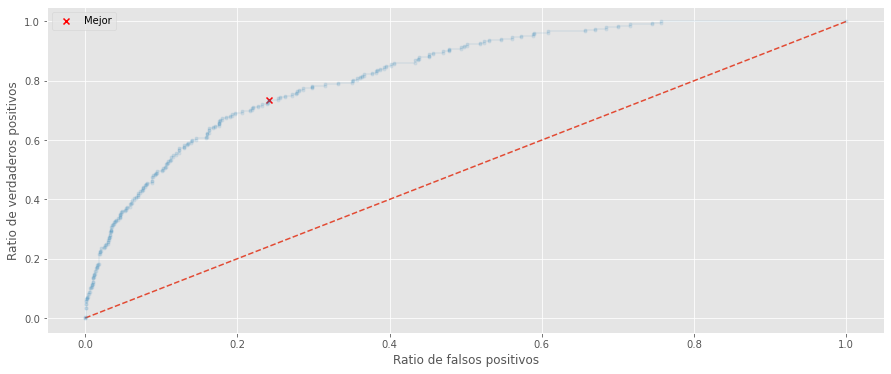

In [24]:
plt.subplots(figsize = (15,6))
plt.plot([0,1], [0,1], linestyle = '--')
plt.plot(fpr, tpr, marker = '.', alpha = .1)
plt.scatter(fpr[ix], tpr[ix], marker = 'x', color = 'red', label = 'Mejor')
plt.xlabel('Ratio de falsos positivos')
plt.ylabel('Ratio de verdaderos positivos')
plt.legend()

En los resultados anteriores puede verse que se ha obtenido un clasificador razonablemente bueno (82% de ROC) que logra un Recall aceptable, estableciendo un corte muy particular, y a costa de sobrevalorar mucho a la clase minoritaria. En realidad, los resultados son decentes, teniendo en cuenta la enorme diferencia que existe entre las dos clases a clasificar.

#### 5.2.2 Entrenamiento empleando Active Learning <a class="anchor" id="5.2.2"></a>

El Active Learning es un método de entrenamiento centrado en obtener modelos que ofrezcan buenos resultados pero que a la vez requieran para ello de un menor número de datos.

Básicamente, el funcionamiento de la estructura de aprendizaje es el siguiente:

 1. Se muestrea un conjunto de datos pequeño y equilibrado, con el que se entrena el modelo.
 2. Se evalúa el modelo en un conjunto equilibrado.
 3. Si el modelo cumple con los criterios, se emplea con un dataset general.
 4. En caso contrario, se realizan nuevos muestreos con la misma proporción de positivos - negativos y repitiendo los datos hasta que se cumplan los criterios o se acaben los datos disponibles.
 
Probablemente, debido a lo escaso de la muestra, particularmente para la clase minoritaria, no se obtendrá un rendimiento óptimo de la técnica.

En primer lugar, se definen los sets de entrenamiento, test y validación, de forma que sean pequeños, y se separan los positivos y negativos.

In [14]:
# Longitudes de los distintos sets
val_split = 150
train_split = 450
test_split = 150

# Separación de positivos y negativos
positivo = data[data['label'] == 1].drop(['Texto', 'ID'], axis = 1)
negativo = data[data['label'] == 0].drop(['Texto', 'ID'], axis = 1)

# Creación de los sets iniciales de entrenamiento, test y validación
validation = pd.concat([positivo[:val_split], negativo[:val_split]]).sample(frac = 1).reset_index()

test = pd.concat([positivo[val_split : val_split + test_split], 
                  negativo[val_split : val_split + test_split]]).sample(frac = 1).reset_index()

train = pd.concat([positivo[val_split + test_split : val_split + test_split + train_split],
                   negativo[val_split + test_split : val_split + test_split + train_split]]).sample(frac = 1)\
.reset_index()

# El resto del dataset se mantiene separado, para emplearse cuando sea necesario
pool_positivo = positivo[val_split + test_split + train_split :].sample(frac = 1).reset_index()
pool_negativo = negativo[val_split + test_split + train_split :].sample(frac = 1).reset_index()

print(f"Tamaño del set de entrenamiento inicial: {len(train)}")
print(f"Tamaño del set de validación: {len(validation)}")
print(f"Tamaño del set de test: {len(test)}")
print(f"Grupo negativo sin etiquetas: {len(pool_negativo)}")
print(f"Grupo positivo sin etiquetas: {len(pool_positivo)}")

Tamaño del set de entrenamiento inicial: 900
Tamaño del set de validación: 300
Tamaño del set de test: 300
Grupo negativo sin etiquetas: 20027
Grupo positivo sin etiquetas: 388


Va a emplearse en este apartado un modelo con una arquitectura similar al anterior.

In [15]:
def create_model():
    inputs = keras.Input(shape=(train.shape[-1]-2,))
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.Dropout(.25)(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=inputs, outputs=output)
    model.summary()
    return model

In [16]:
def append_history(losses, val_losses, accuracy, val_accuracy, history):
    losses = losses + history.history["loss"]
    val_losses = val_losses + history.history["val_loss"]
    accuracy = accuracy + history.history["binary_accuracy"]
    val_accuracy = val_accuracy + history.history["val_binary_accuracy"]
    return losses, val_losses, accuracy, val_accuracy

def plot_history(losses, val_losses, accuracies, val_accuracies):
    plt.subplots(figsize = (15,6))
    plt.plot(losses)
    plt.plot(val_losses)
    plt.legend(["train_loss", "val_loss"])
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()
    
    plt.subplots(figsize = (15,6))
    plt.plot(accuracies)
    plt.plot(val_accuracies)
    plt.legend(["train_accuracy", "val_accuracy"])
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.show()

In [17]:
def train_active_learning_models(train, pool_negativo, pool_positivo, validation, test, num_iterations=5, sampling_size= 200):

    # Creación de listas para almacenar métricas
    losses, val_losses, accuracies, val_accuracies = [], [], [], []

    model = create_model()
    
    model.compile(loss = "binary_crossentropy",
        optimizer = "adam",
        metrics=[keras.metrics.BinaryAccuracy(), keras.metrics.FalseNegatives(), keras.metrics.FalsePositives()])

    # Definición de checkpoints.
    checkpoint = keras.callbacks.ModelCheckpoint( "Pesos métricas/AL/AL_Model.h5", save_best_only = True, verbose = 1)
    early_stopping = keras.callbacks.EarlyStopping(patience = 4, verbose = 1)

    print(f"Iniciar el entrenamiento con {len(train)} muestras")
    
    # Entrenamiento 
    history = model.fit(train.drop(['label', 'index'], 1), train['label'], epochs=20, 
                        validation_data = (validation.drop(['label', 'index'], 1), validation['label']), 
                        callbacks = [checkpoint, early_stopping])

    # Apéndices al historial del modelo
    losses, val_losses, accuracies, val_accuracies = append_history(losses, val_losses, accuracies, val_accuracies, history)

    for iteration in range(num_iterations):
        # Generar predicciones del modelo entrenado
        predictions = model.predict(test.drop(['label', 'index'], 1))

        # Generar etiquetas de las predicciones
        rounded = tf.where(tf.greater(predictions, 0.5), 1, 0)

        # Evaluar número de ceros y unos incorrectamente clasificados
        _, _, false_negatives, false_positives = model.evaluate(test.drop(['label', 'index'], 1), test['label'], verbose=0)

        print("-" * 100)
        print(f"Número de ceros incorrectos: {false_negatives}, Número de unos incorrectos: {false_positives}")
        
        if false_negatives != 0 and false_positives != 0:
            total = false_negatives + false_positives
            sample_ratio_ones, sample_ratio_zeros = (false_positives / total, false_negatives / total)
            
        # En caso de que todas las muestras clasifiquen correctamente, se puede muestrear ambas clases por igual
        else:
            sample_ratio_ones, sample_ratio_zeros = 0.5, 0.5

        print( f"Ratio de muestreo para positivos: {sample_ratio_ones}, Ratio de muestreo para negativos:{sample_ratio_zeros}")

        # Muestreo de unos y ceros requeridos
        sampled = pd.concat([pool_negativo[:int(sample_ratio_zeros * sampling_size)], 
                             pool_positivo[:int(sample_ratio_zeros * sampling_size)]]).sample(frac = 1).reset_index(drop = True)

        # Omisión de puntos empleados para evitar repetición de la muestra
        pool_negativo = pool_negativo[int(sample_ratio_zeros * sampling_size):].reset_index(drop = True)
        pool_positivo = pool_positivo[int(sample_ratio_zeros * sampling_size):].reset_index(drop = True)

         # Concatenación del dataset de entrenamiento con el de muestreo
        train = pd.concat([train, sampled]).reset_index(drop = True)

        print(f"Entrenamiento inicial con {len(train)} muestras")
        print("-" * 100)

        # Recompilación del modelo para resetear el estado del optimizador y reentrenar el modelo
        model.compile(
            loss = "binary_crossentropy", optimizer = "adam",
            metrics = [keras.metrics.BinaryAccuracy(), keras.metrics.FalseNegatives(), keras.metrics.FalsePositives()])
        
        history = model.fit(train.drop(['label', 'index'], 1), train['label'], 
                            validation_data = (validation.drop(['label', 'index'], 1), validation['label']), epochs=20,
                            callbacks=[checkpoint, keras.callbacks.EarlyStopping(patience=4, verbose=1)])

        losses, val_losses, accuracies, val_accuracies = append_history(losses, val_losses, accuracies, val_accuracies, history)

        # Carga del mejor modelo de entrenado en la iteración
        model = keras.models.load_model("Pesos métricas/AL/AL_Model.h5")

    # Graficando la historia y evaluando el modelo final
    plot_history(losses, val_losses, accuracies, val_accuracies)
    print("-" * 100)
    print("Evaluación del set de test: ", model.evaluate(test.drop(['label', 'index'], 1), test['label'], verbose=0, 
                                                         return_dict=True),)
    print("-" * 100)
    print(' ')
    y_pred = model.predict(test.drop(['label', 'index'], 1))
    print(roc_auc_score(test['label'], y_pred))
    print('='*50)
    fpr, tpr, thresholds = roc_curve(test['label'], y_pred)
    ix = np.argmax(np.sqrt(tpr * (1-fpr)))
    print('Mejor Threshold = %f' % (thresholds[ix]))
    print(classification_report(test['label'], [1 if i >= thresholds[ix] else 0 for i in y_pred]))
    
    plt.subplots(figsize = (15,6))
    plt.plot([0,1], [0,1], linestyle = '--')
    plt.plot(fpr, tpr, marker = '.', alpha = .25)
    plt.scatter(fpr[ix], tpr[ix], marker = 'x', color = 'red', label = 'Mejor')
    plt.xlabel('Ratio de falsos positivos')
    plt.ylabel('Ratio de verdaderos positivos')
    plt.legend()

    return model, train

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 32)]              0         
                                                                 
 dense_2 (Dense)             (None, 256)               8448      
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 1)                 257       
                                                                 
Total params: 8,705
Trainable params: 8,705
Non-trainable params: 0
_________________________________________________________________
Iniciar el entrenamiento con 900 muestras
Epoch 1/20


In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.


29/29 [==============================] - ETA: 0s - loss: 10.8912 - binary_accuracy: 0.5633 - false_negatives: 158.0000 - false_positives: 235.0000 
Epoch 1: val_loss improved from inf to 3.28678, saving model to Pesos métricas/AL\AL_Model.h5
29/29 [==============================] - 2s 28ms/step - loss: 10.8912 - binary_accuracy: 0.5633 - false_negatives: 158.0000 - false_positives: 235.0000 - val_loss: 3.2868 - val_binary_accuracy: 0.6967 - val_false_negatives: 41.0000 - val_false_positives: 50.0000
Epoch 2/20
26/29 [=========================>....] - ETA: 0s - loss: 9.8626 - binary_accuracy: 0.5986 - false_negatives: 171.0000 - false_positives: 163.0000
Epoch 2: val_loss improved from 3.28678 to 2.48101, saving model to Pesos métricas/AL\AL_Model.h5
29/29 [==============================] - 0s 8ms/step - loss: 9.8678 - binary_accuracy: 0.6033 - false_negatives: 183.0000 - false_positives: 174.0000 - val_loss: 2.4810 - val_binary_accuracy: 0.6967 - val_false_negatives: 53.0000 - val_fals

In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.


----------------------------------------------------------------------------------------------------
Número de ceros incorrectos: 32.0, Número de unos incorrectos: 64.0
Ratio de muestreo para positivos: 0.6666666666666666, Ratio de muestreo para negativos:0.3333333333333333
Entrenamiento inicial con 1032 muestras
----------------------------------------------------------------------------------------------------
Epoch 1/20


In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.


21/33 [==================>...........] - ETA: 0s - loss: 4.9719 - binary_accuracy: 0.6488 - false_negatives_1: 119.0000 - false_positives_1: 117.0000
Epoch 1: val_loss improved from 2.48101 to 1.74343, saving model to Pesos métricas/AL\AL_Model.h5
33/33 [==============================] - 2s 29ms/step - loss: 4.7733 - binary_accuracy: 0.6395 - false_negatives_1: 189.0000 - false_positives_1: 183.0000 - val_loss: 1.7434 - val_binary_accuracy: 0.6900 - val_false_negatives_1: 27.0000 - val_false_positives_1: 66.0000
Epoch 2/20
28/33 [========================>.....] - ETA: 0s - loss: 4.2686 - binary_accuracy: 0.6373 - false_negatives_1: 168.0000 - false_positives_1: 157.0000
Epoch 2: val_loss improved from 1.74343 to 1.27665, saving model to Pesos métricas/AL\AL_Model.h5
33/33 [==============================] - 0s 7ms/step - loss: 4.1242 - binary_accuracy: 0.6453 - false_negatives_1: 184.0000 - false_positives_1: 182.0000 - val_loss: 1.2766 - val_binary_accuracy: 0.6767 - val_false_negative

33/33 [==============================] - 0s 7ms/step - loss: 0.7579 - binary_accuracy: 0.6725 - false_negatives_1: 191.0000 - false_positives_1: 147.0000 - val_loss: 0.5566 - val_binary_accuracy: 0.7100 - val_false_negatives_1: 63.0000 - val_false_positives_1: 24.0000
Epoch 18/20
25/33 [=====================>........] - ETA: 0s - loss: 0.6946 - binary_accuracy: 0.6913 - false_negatives_1: 125.0000 - false_positives_1: 122.0000
Epoch 18: val_loss did not improve from 0.55657
33/33 [==============================] - 0s 6ms/step - loss: 0.7272 - binary_accuracy: 0.6899 - false_negatives_1: 155.0000 - false_positives_1: 165.0000 - val_loss: 0.6767 - val_binary_accuracy: 0.5767 - val_false_negatives_1: 125.0000 - val_false_positives_1: 2.0000
Epoch 19/20
32/33 [============================>.] - ETA: 0s - loss: 0.7473 - binary_accuracy: 0.6768 - false_negatives_1: 198.0000 - false_positives_1: 133.0000
Epoch 19: val_loss improved from 0.55657 to 0.54305, saving model to Pesos métricas/AL\AL_

In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.


----------------------------------------------------------------------------------------------------
Número de ceros incorrectos: 54.0, Número de unos incorrectos: 51.0
Ratio de muestreo para positivos: 0.4857142857142857, Ratio de muestreo para negativos:0.5142857142857142
Entrenamiento inicial con 1236 muestras
----------------------------------------------------------------------------------------------------
Epoch 1/20


In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.


37/39 [===========================>..] - ETA: 0s - loss: 0.7869 - binary_accuracy: 0.6689 - false_negatives_2: 195.0000 - false_positives_2: 197.0000
Epoch 1: val_loss did not improve from 0.54305
39/39 [==============================] - 2s 19ms/step - loss: 0.7858 - binary_accuracy: 0.6707 - false_negatives_2: 206.0000 - false_positives_2: 201.0000 - val_loss: 0.5753 - val_binary_accuracy: 0.6700 - val_false_negatives_2: 74.0000 - val_false_positives_2: 25.0000
Epoch 2/20
32/39 [=======================>......] - ETA: 0s - loss: 0.6743 - binary_accuracy: 0.6748 - false_negatives_2: 184.0000 - false_positives_2: 149.0000
Epoch 2: val_loss did not improve from 0.54305
39/39 [==============================] - 0s 4ms/step - loss: 0.6645 - binary_accuracy: 0.6788 - false_negatives_2: 206.0000 - false_positives_2: 191.0000 - val_loss: 0.5447 - val_binary_accuracy: 0.6733 - val_false_negatives_2: 42.0000 - val_false_positives_2: 56.0000
Epoch 3/20
38/39 [============================>.] - ETA:

Epoch 18/20
36/39 [==========================>...] - ETA: 0s - loss: 0.5473 - binary_accuracy: 0.7092 - false_negatives_2: 106.0000 - false_positives_2: 229.0000
Epoch 18: val_loss did not improve from 0.53009
39/39 [==============================] - 0s 5ms/step - loss: 0.5423 - binary_accuracy: 0.7136 - false_negatives_2: 117.0000 - false_positives_2: 237.0000 - val_loss: 0.5529 - val_binary_accuracy: 0.6767 - val_false_negatives_2: 54.0000 - val_false_positives_2: 43.0000
Epoch 18: early stopping
10/10 [==============================] - 0s 2ms/step


In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.


----------------------------------------------------------------------------------------------------
Número de ceros incorrectos: 40.0, Número de unos incorrectos: 60.0
Ratio de muestreo para positivos: 0.6, Ratio de muestreo para negativos:0.4
Entrenamiento inicial con 1396 muestras
----------------------------------------------------------------------------------------------------
Epoch 1/20


In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.


39/44 [=========================>....] - ETA: 0s - loss: 0.5747 - binary_accuracy: 0.7051 - false_negatives_3: 141.0000 - false_positives_3: 227.0000
Epoch 1: val_loss did not improve from 0.53009
44/44 [==============================] - 2s 19ms/step - loss: 0.5731 - binary_accuracy: 0.7042 - false_negatives_3: 158.0000 - false_positives_3: 255.0000 - val_loss: 0.5711 - val_binary_accuracy: 0.6867 - val_false_negatives_3: 25.0000 - val_false_positives_3: 69.0000
Epoch 2/20
34/44 [======================>.......] - ETA: 0s - loss: 0.5445 - binary_accuracy: 0.7077 - false_negatives_3: 116.0000 - false_positives_3: 202.0000
Epoch 2: val_loss did not improve from 0.53009
44/44 [==============================] - 0s 4ms/step - loss: 0.5569 - binary_accuracy: 0.7135 - false_negatives_3: 153.0000 - false_positives_3: 247.0000 - val_loss: 0.5403 - val_binary_accuracy: 0.6900 - val_false_negatives_3: 31.0000 - val_false_positives_3: 62.0000
Epoch 3/20
38/44 [========================>.....] - ETA:

In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.


----------------------------------------------------------------------------------------------------
Número de ceros incorrectos: 40.0, Número de unos incorrectos: 60.0
Ratio de muestreo para positivos: 0.6, Ratio de muestreo para negativos:0.4
Entrenamiento inicial con 1556 muestras
----------------------------------------------------------------------------------------------------
Epoch 1/20


In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.


46/49 [===========================>..] - ETA: 0s - loss: 0.5747 - binary_accuracy: 0.7086 - false_negatives_4: 170.0000 - false_positives_4: 259.0000
Epoch 1: val_loss did not improve from 0.53009
49/49 [==============================] - 3s 17ms/step - loss: 0.5727 - binary_accuracy: 0.7082 - false_negatives_4: 184.0000 - false_positives_4: 270.0000 - val_loss: 0.5419 - val_binary_accuracy: 0.6900 - val_false_negatives_4: 33.0000 - val_false_positives_4: 60.0000
Epoch 2/20
29/49 [================>.............] - ETA: 0s - loss: 0.5665 - binary_accuracy: 0.7004 - false_negatives_4: 116.0000 - false_positives_4: 162.0000
Epoch 2: val_loss did not improve from 0.53009
49/49 [==============================] - 0s 4ms/step - loss: 0.5650 - binary_accuracy: 0.7102 - false_negatives_4: 174.0000 - false_positives_4: 277.0000 - val_loss: 0.5510 - val_binary_accuracy: 0.6867 - val_false_negatives_4: 38.0000 - val_false_positives_4: 56.0000
Epoch 3/20
34/49 [===================>..........] - ETA:

In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.


10/10 [==============================] - 0s 4ms/step


In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.


----------------------------------------------------------------------------------------------------
Número de ceros incorrectos: 40.0, Número de unos incorrectos: 60.0
Ratio de muestreo para positivos: 0.6, Ratio de muestreo para negativos:0.4
Entrenamiento inicial con 1696 muestras
----------------------------------------------------------------------------------------------------
Epoch 1/20


In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.


46/53 [=========================>....] - ETA: 0s - loss: 0.5788 - binary_accuracy: 0.6977 - false_negatives_5: 152.0000 - false_positives_5: 293.0000
Epoch 1: val_loss did not improve from 0.53009
53/53 [==============================] - 2s 14ms/step - loss: 0.5805 - binary_accuracy: 0.6934 - false_negatives_5: 180.0000 - false_positives_5: 340.0000 - val_loss: 0.5437 - val_binary_accuracy: 0.6733 - val_false_negatives_5: 39.0000 - val_false_positives_5: 59.0000
Epoch 2/20
40/53 [=====================>........] - ETA: 0s - loss: 0.5607 - binary_accuracy: 0.7055 - false_negatives_5: 146.0000 - false_positives_5: 231.0000
Epoch 2: val_loss did not improve from 0.53009
53/53 [==============================] - 0s 3ms/step - loss: 0.5568 - binary_accuracy: 0.7070 - false_negatives_5: 179.0000 - false_positives_5: 318.0000 - val_loss: 0.5523 - val_binary_accuracy: 0.6833 - val_false_negatives_5: 35.0000 - val_false_positives_5: 60.0000
Epoch 3/20
37/53 [===================>..........] - ETA:

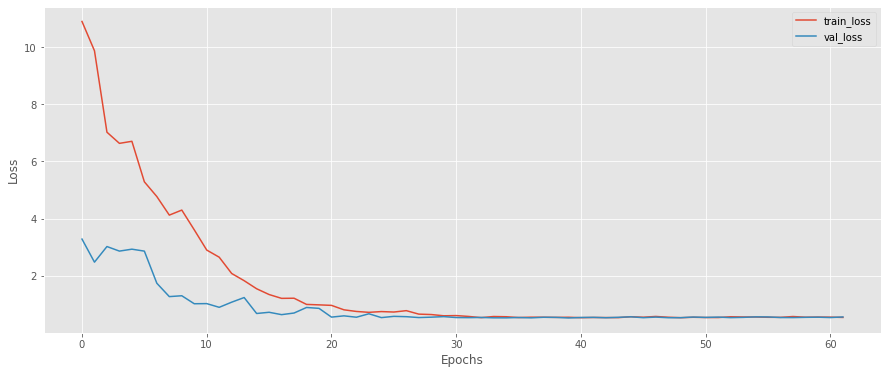

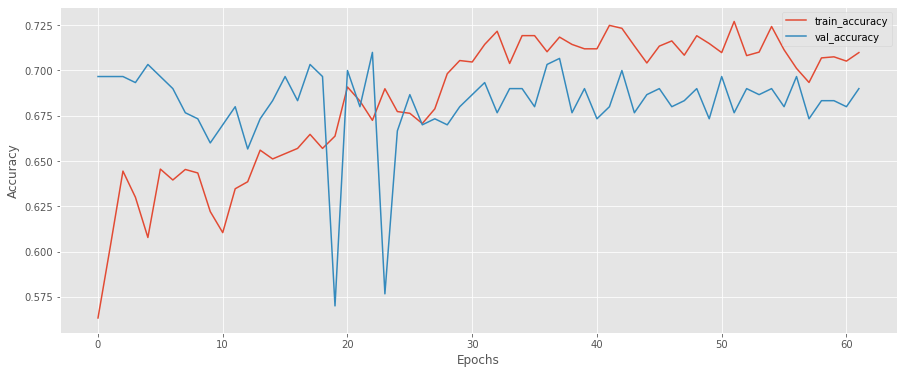

----------------------------------------------------------------------------------------------------


In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.


Evaluación del set de test:  {'loss': 0.6006050705909729, 'binary_accuracy': 0.6666666865348816, 'false_negatives_2': 40.0, 'false_positives_2': 60.0}
----------------------------------------------------------------------------------------------------
 
10/10 [==============================] - 0s 2ms/step
0.7559111111111111
Mejor Threshold = 0.524601
              precision    recall  f1-score   support

           0       0.68      0.67      0.68       150
           1       0.68      0.69      0.68       150

    accuracy                           0.68       300
   macro avg       0.68      0.68      0.68       300
weighted avg       0.68      0.68      0.68       300



In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.


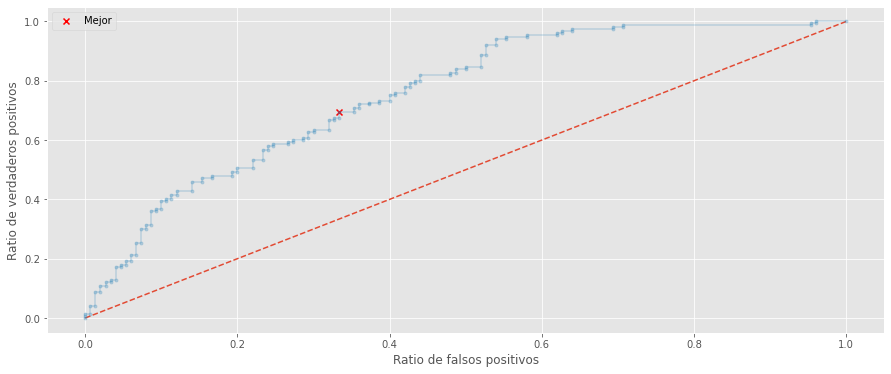

In [29]:
model, train = train_active_learning_models(train, pool_negativo, pool_positivo, validation, test)

 37/657 [>.............................] - ETA: 0s 

In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.


657/657 [==============================] - 1s 2ms/step
0.5615319254033757
Mejor Threshold = 1.000000
              precision    recall  f1-score   support

           0       1.00      0.13      0.23     20327
           1       0.04      0.99      0.07       688

    accuracy                           0.16     21015
   macro avg       0.52      0.56      0.15     21015
weighted avg       0.97      0.16      0.23     21015



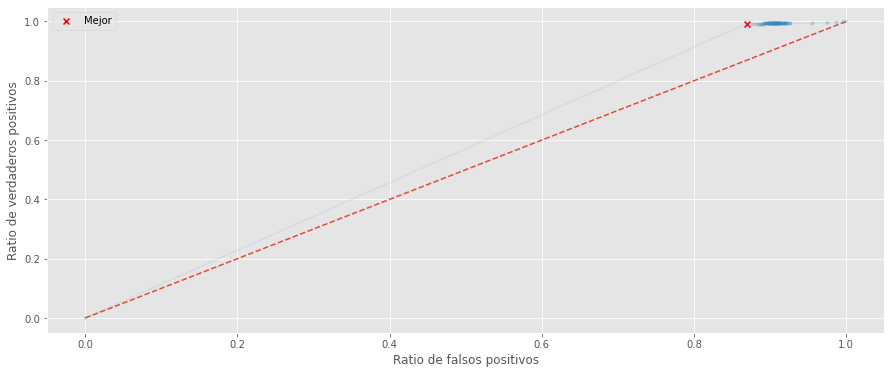

In [18]:
y_pred = model.predict(data.drop(train['index']).drop(['label', 'Texto', 'ID'], 1))
y_val = data.drop(train['index'].values)['label']
print(roc_auc_score(y_val, y_pred))
print('='*50)
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
ix = np.argmax(np.sqrt(tpr * (1-fpr)))
print('Mejor Threshold = %f' % (thresholds[ix]))
print(classification_report(y_val, [1 if i >= thresholds[ix] else 0 for i in y_pred]))
    
plt.subplots(figsize = (15,6))
plt.plot([0,1], [0,1], linestyle = '--')
plt.plot(fpr, tpr, marker = '.', alpha = .1)
plt.scatter(fpr[ix], tpr[ix], marker = 'x', color = 'red', label = 'Mejor')
plt.xlabel('Ratio de falsos positivos')
plt.ylabel('Ratio de verdaderos positivos')
plt.legend()

Como puede verse, se obtienen rendimientos más bajos que en el primer apartado. Esto posblemente sea debido al bajo volumen de la muestra pero, en cualquier caso, resulta obvio que esta técnica no es adecuada para nuestro caso.

#### 5.2.3 Entrenamiento empleando redes amplias, profundas y cruzadas <a class="anchor" id="5.2.3"></a>

Este apartado llevará a cabo una prueba de dos técnicas novedosas de modelado:
 - Los modelos Amplios y Profundos 
 - Los modelos Profundos y Cruzados
 
Primero se llevará a cabo la tradicional separación entre set de entrenamiento y de validación, y luego se definirán los parámetros generales de los modelos.

In [19]:
# Separación en sets de entrenamiento y validación
validation = data.sample(4000, random_state = 42)
train = data.drop(validation.index)

X_train, X_val, y_train, y_val = (train.drop(['label', 'Texto', 'ID'], axis = 1), 
                                  validation.drop(['label', 'Texto', 'ID'], axis = 1), 
                                  train['label'], validation['label'])

In [20]:
dropout_rate = 0.1
batch_size = 265
num_epochs = 20

hidden_units = [128, 128]

Como puede verse, el primer modelo es aún más simple, en cuanto a parámetros, aunque no en cuanto a estructura que el utilizado en los dos apartados anteriores.

In [21]:
def WideDeepModel():

    inputs = keras.Input(shape = (X_train.shape[-1],))
    wide = layers.BatchNormalization()(inputs)

    for units in hidden_units:
        deep = layers.Dense(units)(inputs)
        deep = layers.BatchNormalization()(deep)
        deep = layers.ReLU()(deep)
        deep = layers.Dropout(dropout_rate)(deep)

    merged = layers.concatenate([wide, deep])
    outputs = layers.Dense(units = 1, activation = "sigmoid")(merged)
    model = keras.Model(inputs = inputs, outputs = outputs)
    return model

In [22]:
model = WideDeepModel()
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 32)]         0           []                               
                                                                                                  
 dense_3 (Dense)                (None, 128)          4224        ['input_2[0][0]']                
                                                                                                  
 batch_normalization_2 (BatchNo  (None, 128)         512         ['dense_3[0][0]']                
 rmalization)                                                                                     
                                                                                                  
 re_lu_1 (ReLU)                 (None, 128)          0           ['batch_normalization_2[0][

In [ ]:
model.compile("adam", "binary_crossentropy", metrics = ['accuracy', tf.keras.metrics.AUC(from_logits = True)])

callbacks = [tf.keras.callbacks.ModelCheckpoint(
              filepath = 'Pesos métricas/WideDeep/weights.{epoch:02d}-{val_auc:.4f}.hdf5',
              monitor = 'val_auc',
              save_best_only = False, save_weights_only = True)]

history = model.fit(X_train, y_train, epochs = num_epochs, validation_data = (X_val, y_val), callbacks = callbacks)

125/125 [==============================] - 0s 2ms/step
0.8263753651411879
Mejor Threshold = 0.073147
              precision    recall  f1-score   support

           0       0.98      0.78      0.87      3792
           1       0.15      0.73      0.25       208

    accuracy                           0.78      4000
   macro avg       0.57      0.75      0.56      4000
weighted avg       0.94      0.78      0.84      4000



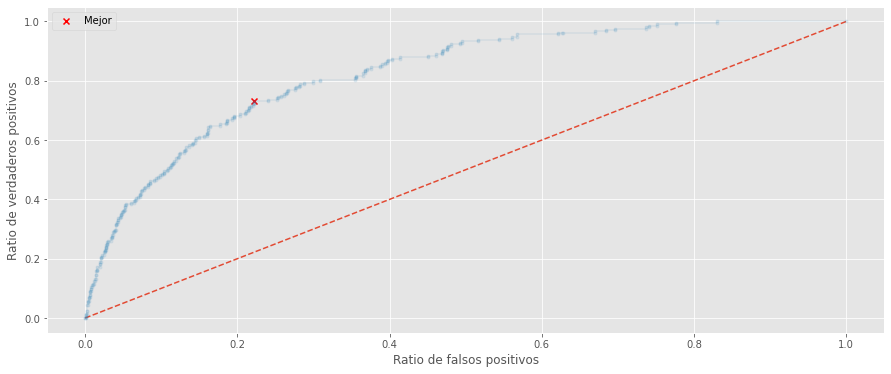

In [24]:
model.load_weights('Pesos métricas/WideDeep/weights.13-0.8236.hdf5')

y_pred = model.predict(X_val)
print(roc_auc_score(y_val, y_pred))
print('='*50)
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
ix = np.argmax(np.sqrt(tpr * (1-fpr)))
print('Mejor Threshold = %f' % (thresholds[ix]))
print(classification_report(y_val, [1 if i >= thresholds[ix] else 0 for i in y_pred]))
    
plt.subplots(figsize = (15,6))
plt.plot([0,1], [0,1], linestyle = '--')
plt.plot(fpr, tpr, marker = '.', alpha = .1)
plt.scatter(fpr[ix], tpr[ix], marker = 'x', color = 'red', label = 'Mejor')
plt.xlabel('Ratio de falsos positivos')
plt.ylabel('Ratio de verdaderos positivos')
plt.legend()

Los resultados de este primer modelo, como puede verse, son similares o, incluso, ligeramente mejores que los del primer apartado. Ahora se probará igualmente con el siguiente modelo que, como puede verse, tiene una mayor cantidad de parámetros y una mayor complejidad estructural.

In [25]:
def DeepCrossModel():

    inputs = keras.Input(shape = (X_train.shape[-1],))

    cross = inputs
    for _ in hidden_units:
        units = cross.shape[-1]
        x = layers.Dense(units)(cross)
        cross = inputs * x + cross
    cross = layers.BatchNormalization()(cross)

    deep = inputs
    for units in hidden_units:
        deep = layers.Dense(units)(deep)
        deep = layers.BatchNormalization()(deep)
        deep = layers.ReLU()(deep)
        deep = layers.Dropout(dropout_rate)(deep)

    merged = layers.concatenate([cross, deep])
    outputs = layers.Dense(units = 1, activation = "sigmoid")(merged)
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

In [38]:
model = DeepCrossModel()
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 32)]         0           []                               
                                                                                                  
 dense_9 (Dense)                (None, 128)          4224        ['input_7[0][0]']                
                                                                                                  
 dense_7 (Dense)                (None, 32)           1056        ['input_7[0][0]']                
                                                                                                  
 batch_normalization_6 (BatchNo  (None, 128)         512         ['dense_9[0][0]']                
 rmalization)                                                                               

In [ ]:
model.compile("adam", "binary_crossentropy", metrics = ['accuracy', tf.keras.metrics.AUC(from_logits = True)])

callbacks = [tf.keras.callbacks.ModelCheckpoint(
              filepath = 'Pesos métricas/DeepCross/weights.{epoch:02d}-{val_auc:.4f}.hdf5',
              monitor = 'val_auc',
              save_best_only = False, save_weights_only = True)]

history = model.fit(X_train, y_train, epochs = num_epochs, validation_data = (X_val, y_val), callbacks = callbacks)

125/125 [==============================] - 0s 2ms/step
0.8289345230850372
Mejor Threshold = 0.083438
              precision    recall  f1-score   support

           0       0.98      0.77      0.86      3792
           1       0.15      0.74      0.25       208

    accuracy                           0.77      4000
   macro avg       0.57      0.76      0.56      4000
weighted avg       0.94      0.77      0.83      4000



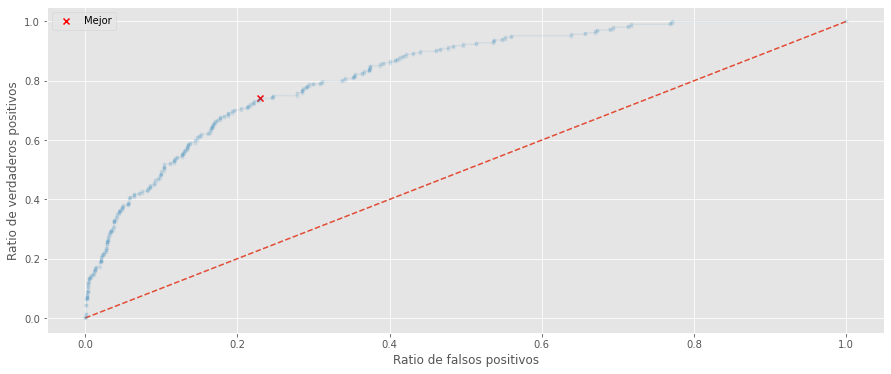

In [40]:
model.load_weights('Pesos métricas/DeepCross/weights.15-0.8259.hdf5')

y_pred = model.predict(X_val)
print(roc_auc_score(y_val, y_pred))
print('='*50)
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
ix = np.argmax(np.sqrt(tpr * (1-fpr)))
print('Mejor Threshold = %f' % (thresholds[ix]))
print(classification_report(y_val, [1 if i >= thresholds[ix] else 0 for i in y_pred]))
    
plt.subplots(figsize = (15,6))
plt.plot([0,1], [0,1], linestyle = '--')
plt.plot(fpr, tpr, marker = '.', alpha = .1)
plt.scatter(fpr[ix], tpr[ix], marker = 'x', color = 'red', label = 'Mejor')
plt.xlabel('Ratio de falsos positivos')
plt.ylabel('Ratio de verdaderos positivos')
plt.legend()

Los resultados son muy similares a los anteriores, con una mejoría casi imperceptible y despreciable en términos prácticos. 

Se probará, en este apartado, un último modelo, en el que se combinarán todas las capas anteriores. El modelo resultante tendrá un volumen de parámetros parecido al anterior.

In [41]:
def WideDeepCrossModel():
    inputs = keras.Input(shape = (X_train.shape[-1],))
    wide = layers.BatchNormalization()(inputs)
    
    cross = inputs
    for _ in hidden_units:
        units = cross.shape[-1]
        x = layers.Dense(units)(cross)
        cross = inputs * x + cross
    cross = layers.BatchNormalization()(cross)
    
    deep = inputs
    for units in hidden_units:
        deep = layers.Dense(units)(deep)
        deep = layers.BatchNormalization()(deep)
        deep = layers.ReLU()(deep)
        deep = layers.Dropout(dropout_rate)(deep)

    merged = layers.concatenate([wide, cross, deep])
    outputs = layers.Dense(units = 1, activation = "sigmoid")(merged)
    model = keras.Model(inputs = inputs, outputs = outputs)
    return model

In [42]:
model = WideDeepCrossModel()
model.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_8 (InputLayer)           [(None, 32)]         0           []                               
                                                                                                  
 dense_14 (Dense)               (None, 128)          4224        ['input_8[0][0]']                
                                                                                                  
 dense_12 (Dense)               (None, 32)           1056        ['input_8[0][0]']                
                                                                                                  
 batch_normalization_10 (BatchN  (None, 128)         512         ['dense_14[0][0]']               
 ormalization)                                                                              

In [ ]:
model.compile("adam", "binary_crossentropy", metrics = ['accuracy', tf.keras.metrics.AUC(from_logits = True)])

callbacks = [tf.keras.callbacks.ModelCheckpoint(
              filepath = 'Pesos métricas/WideDeepCross/weights.{epoch:02d}-{val_auc:.4f}.hdf5',
              monitor = 'val_auc',
              save_best_only = False, save_weights_only = True)]

history = model.fit(X_train, y_train, epochs = num_epochs, validation_data = (X_val, y_val), callbacks = callbacks)

125/125 [==============================] - 0s 2ms/step
0.8324154089581305
Mejor Threshold = 0.069445
              precision    recall  f1-score   support

           0       0.98      0.76      0.85      3792
           1       0.14      0.74      0.24       208

    accuracy                           0.76      4000
   macro avg       0.56      0.75      0.55      4000
weighted avg       0.94      0.76      0.82      4000



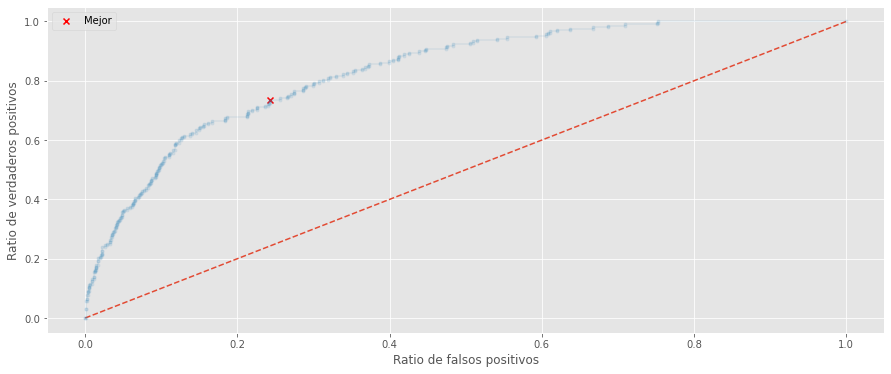

In [44]:
model.load_weights('Pesos métricas/WideDeepCross/weights.17-0.8281.hdf5')

y_pred = model.predict(X_val)
print(roc_auc_score(y_val, y_pred))
print('='*50)
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
ix = np.argmax(np.sqrt(tpr * (1-fpr)))
print('Mejor Threshold = %f' % (thresholds[ix]))
print(classification_report(y_val, [1 if i >= thresholds[ix] else 0 for i in y_pred]))
    
plt.subplots(figsize = (15,6))
plt.plot([0,1], [0,1], linestyle = '--')
plt.plot(fpr, tpr, marker = '.', alpha = .1)
plt.scatter(fpr[ix], tpr[ix], marker = 'x', color = 'red', label = 'Mejor')
plt.xlabel('Ratio de falsos positivos')
plt.ylabel('Ratio de verdaderos positivos')
plt.legend()

En este caso la mejora también es pequeña, aunque es más evidente.

### 5.3. Predicción sólo con transcripciones <a class="anchor" id="5.3"></a>

La modelización únicamente con transcripciones se llevará a cabo mediante un modelo basado en transformers. Es una arquitectura relativamente reciente en la que se construyen actualmente gran parte de los modelos de lenguaje empleados a día de hoy, tales como la serie GPT de OpenAI, el modelo BERT o los modelos de Google, Amazon o Apple. 

Estos modelos tienen la ventaja de que no es necesario aplicar transformaciones sobre la información desestructurada, que vale tanto para textos, como para series temporales o imágenes, para llevar a cabo la modelización, tales como técnicas de tipo Bolsa de palabras, TF-IDF o PCAs.

El esquema del modelo sería el siguiente:
![Esquema de la Arquitectura de un modelo de clasificación con Transformers](descarga.png)

Donde, en la primera capa, podría introducirse un texto cualquiera que sería vectorizado en la capa de vectorización. El texto vectorizado pasaría a una capa de embebido y luego a una de posicionamiento. De ahí atravesaría la capa de transformer, una capa de normalización, una ultima capa normal y, finalmente, la capa que daría el resultado.

Por desgracia, en el periodo de entrenamiento no puede incluirse la capa de preprocesado, sino que debe añadirse a posteriori para futuras predicciones, lo cual es extremadamente util, pues facilita su exportación y productivización sin necesidad deexportar un objeto para el preproceso entrenado a parte.

En el caso presente, va a emplearse una limpieza de las transcripciones, a fin de optimizar esta veztorización. Ésta consistirá en la eliminación de acentos, caracteres especiales o signos de puntuación, la conversión de todos los caracteres a minúscula y la eliminación de palabras vacías.

In [ ]:
data['Texto'] = data['Texto'].apply(Transformers.clean_text)

validation = data.sample(4000, random_state = 42)
train = data.drop(validation.index)

X_train, X_val, y_train, y_val = train['Texto'], validation['Texto'], train['label'], validation['label']

A continuación se define el número máximo de plabras que van a tenerse en cuenta (por frecuencia en el corpus) y la longitud máxima de las secuencias para cada llamada. Se considerarán las 20 000 palabras más frecuentes y una longitud máxima de 750 palabras por llamada.

Esto es necesario para optimizar recursos y asegurar que el tiempo y el coste computacional del entrenamiento sea razonable.

In [46]:
vocab_size = 20000
maxlen = 750

A continuación se muestra la capa de vectorización, adaptada al texto del corpus de entrenamiento.

In [ ]:
vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens = vocab_size - 1,
    output_mode="int",
    output_sequence_length = maxlen,
)
vectorize_layer.adapt(X_train)

In [ ]:
X_train = vectorize_layer(X_train)
X_val = vectorize_layer(X_val)

El modelo, como puede observarse, es mucho más grande, en término de parámetros, que el resto de modelos. Aún así, debido al reducido volumen de la muestra, sólo se ha adherido un bloque transformer al modelo.

In [49]:
model = Transformers.SimpleTransformer(vocab_size = 20000, maxlen = 750, embed_dim = 750, num_heads = 2, ff_dim = 2048,
                                       n_layers = 1, rate = .2, rate_transformer = .1)

Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_9 (InputLayer)        [(None, 750)]             0         
                                                                 
 token_and_position_embeddin  (None, 750, 750)         15562500  
 g (TokenAndPositionEmbeddin                                     
 g)                                                              
                                                                 
 transformer_block (Transfor  (None, 750, 750)         5330798   
 merBlock)                                                       
                                                                 
 global_average_pooling1d (G  (None, 750)              0         
 lobalAveragePooling1D)                                          
                                                                 
 dropout_10 (Dropout)        (None, 750)               0   

In [ ]:
metrics = ['accuracy', keras.metrics.AUC(from_logits = True)]

model.compile(optimizer = 'Adam', loss = "binary_crossentropy", metrics = metrics)

callbacks = [tf.keras.callbacks.ModelCheckpoint(
              filepath = 'Pesos transcripciones/weights_.{epoch:02d}-{val_auc:.4f}.hdf5',
              monitor = 'val_auc',
              save_best_only = False, save_weights_only = True)]

model.fit(X_train, y_train, batch_size = 256, epochs = 5,
          callbacks = callbacks,
          validation_data = (X_val, y_val)
)

Puede comprobarse como el modelo ha sido mucho más exigente en términos de tiempo que el resto de modelos, pese al reducido número de épocas empleadas en el entrenamiento.

In [ ]:
model.load_weights('Pesos transcripciones/weights_.03-0.9347.hdf5')

A continuación, tomando el mejor modelo, se adhiere la capa entrenada de preprocesado, lo cual permitiría emplear directamente tecto como input del modelo.

In [52]:
inputs = tf.keras.Input(shape = (1,), dtype = 'string')
x = vectorize_layer(inputs)
outputs = model(x)

model = keras.Model(inputs = inputs, outputs = outputs)

In [53]:
metrics = ['accuracy', keras.metrics.AUC(from_logits = True)]

model.compile(optimizer = 'Adam', loss = "binary_crossentropy", metrics = metrics)

In [ ]:
model.save('Pesos transcripciones/Modelo final.tf', save_format = 'tf', include_optimizer = True)

In [ ]:
model = keras.models.load_model('Pesos transcripciones/Modelo final.tf')

Para comprobar que ha funcionado se importa el modelo final para predecir los resultados empleados en la validación.

In [56]:
print(roc_auc_score(y_val, y_pred))
print('='*50)
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
ix = np.argmax(np.sqrt(tpr * (1-fpr)))
print('Mejor Threshold = %f' % (thresholds[ix]))
print(classification_report(y_val, [1 if i >= thresholds[ix] else 0 for i in y_pred]))

0.8324154089581305
Mejor Threshold = 0.069445
              precision    recall  f1-score   support

           0       0.98      0.76      0.85      3792
           1       0.14      0.74      0.24       208

    accuracy                           0.76      4000
   macro avg       0.56      0.75      0.55      4000
weighted avg       0.94      0.76      0.82      4000



In [57]:
print(classification_report(y_val, [1 if i >= .54 else 0 for i in y_pred]))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      3792
           1       0.67      0.06      0.11       208

    accuracy                           0.95      4000
   macro avg       0.81      0.53      0.54      4000
weighted avg       0.94      0.95      0.93      4000



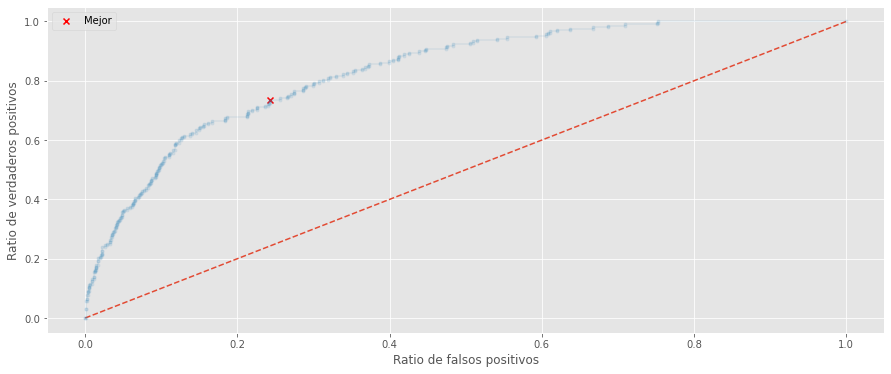

In [58]:
plt.subplots(figsize = (15,6))
plt.plot([0,1], [0,1], linestyle = '--')
plt.plot(fpr, tpr, marker = '.', alpha = .1)
plt.scatter(fpr[ix], tpr[ix], marker = 'x', color = 'red', label = 'Mejor')
plt.xlabel('Ratio de falsos positivos')
plt.ylabel('Ratio de verdaderos positivos')
plt.legend()

Los resultados, como puede verse, son notables, obteniendo un muy buen clasificador (93% de ROC-AUC), que obtiene buenos rendimientos tanto con el corte más ajustado según la curva ROC, como empleando un corte cercano al convencional.

### 5.4 Combinación de modelos <a class="anchor" id="5.4"></a>

Ahora se llevará a cabo una convinación de modelos, empleando tanto el obtenido anteriormente para transcripciones como el mejor modelo obtenido para las métricas. 

In [ ]:
# Separación en sets de entrenamiento y validación
validation = data.sample(4000, random_state = 42)
train = data.drop(validation.index)

X_train, X_val, y_train, y_val = (train.drop(['label', 'Texto', 'ID'], axis = 1), 
                                  validation.drop(['label', 'Texto', 'ID'], axis = 1), 
                                  train['label'], validation['label'])

val_texto = validation['Texto'].apply(Transformers.clean_text)

In [60]:
dropout_rate = 0.1
batch_size = 265
num_epochs = 20

hidden_units = [128, 128]

Una vez se han importado los modelos, se realizará un promedio de las predicciones de cada uno para una misma llamada.

In [ ]:
model_texto = keras.models.load_model('Pesos transcripciones/Modelo final.tf')
model_métricas = WideDeepCrossModel()
model_métricas.load_weights('Pesos métricas/WideDeepCross/weights.17-0.8281.hdf5')

In [ ]:
%%time
y_pred = (model_texto.predict(val_texto)+model_métricas.predict(X_val))/2

0.8324154089581305
Mejor Threshold = 0.069445
              precision    recall  f1-score   support

           0       0.98      0.76      0.85      3792
           1       0.14      0.74      0.24       208

    accuracy                           0.76      4000
   macro avg       0.56      0.75      0.55      4000
weighted avg       0.94      0.76      0.82      4000



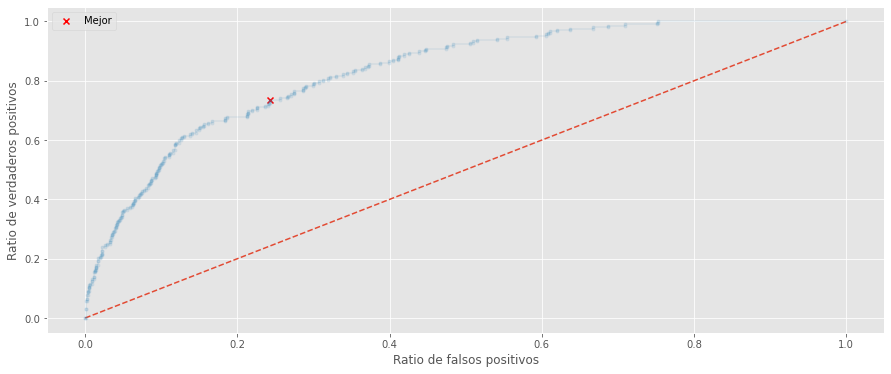

In [63]:
print(roc_auc_score(y_val, y_pred))
print('='*50)
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
ix = np.argmax(np.sqrt(tpr * (1-fpr)))
print('Mejor Threshold = %f' % (thresholds[ix]))
print(classification_report(y_val, [1 if i >= thresholds[ix] else 0 for i in y_pred]))
    
plt.subplots(figsize = (15,6))
plt.plot([0,1], [0,1], linestyle = '--')
plt.plot(fpr, tpr, marker = '.', alpha = .1)
plt.scatter(fpr[ix], tpr[ix], marker = 'x', color = 'red', label = 'Mejor')
plt.xlabel('Ratio de falsos positivos')
plt.ylabel('Ratio de verdaderos positivos')
plt.legend()

In [ ]:
print(classification_report(y_val, [1 if i >= .305 else 0 for i in y_pred]))

Como se puede observar, los resultados de los modelos combinados son incluso mejores que los obtenidos individualmente por el modelo de transcripciones. 

A continuación, puede observarse la matriz de confusión suponiendo un corte equilibrado de 0,305.

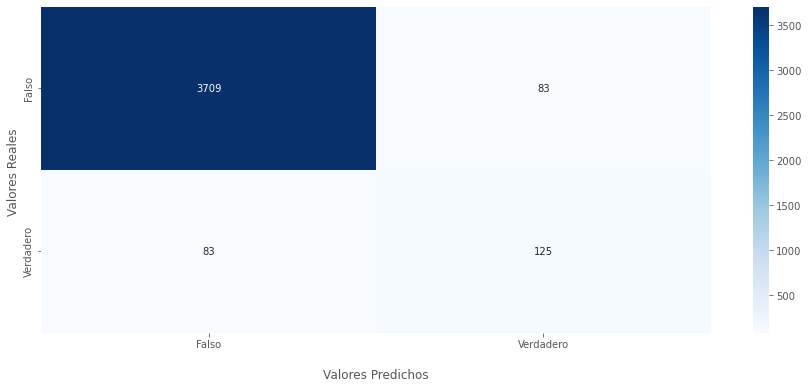

In [14]:
plt.subplots(figsize = (15,6))
ax = sns.heatmap(confusion_matrix(y_val, [1 if i >= .305 else 0 for i in y_pred]), annot=True, cmap='Blues', fmt = '.0f');

ax.set_xlabel('\nValores Predichos');
ax.set_ylabel('Valores Reales ');

ax.xaxis.set_ticklabels(['Falso','Verdadero'])
ax.yaxis.set_ticklabels(['Falso','Verdadero'])

plt.show()

A continuación vamos a usar SHAP (explicaciones aditivas SHapley)
El objetivo de SHAP es explicar la predicción de una instancia x calculando la contribución de cada característica a la predicción. El método de explicación SHAP calcula los valores de Shapley a partir de la teoría de juegos de coalición.


In [1]:
explainer = shap.KernelExplainer(model_métricas, X_val.sample(100))
shap_values = explainer.shap_values(X_val.sample(25))

NameError: name 'shap' is not defined

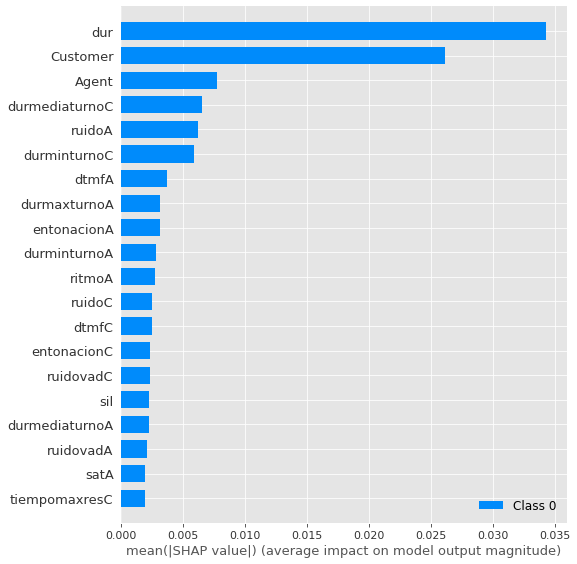

In [149]:
shap.initjs()
shap.summary_plot(shap_values,X_val)

Podemos observar que las variables duracion y Customer son las más explicativas en nuestro modelo para medir el nivel de satisfacción del cliente.
Esto tiene sentido ya que si mantienes un tiempo de asistencia promedio lo más bajo posible, significa que tus representantes son más eficientes por lo que el nivel de satisfacción del cliente tendrá más posibilidades de ser positiva.

## 6. Conclusiones <a class="anchor" id="6"></a>

Vistos los resultados, pueden obtenerse las siguientes conclusiones:

 1. El modelo de lenguaje obtiene mejores resultados que el modelo de métricas. Esto no es algo nuevo, ya que, tradicionalmente, los resultados obtenidos a partir de transcripciones han sido mejores que los obtenidos a partir de métricas. Sin embargo, con la nueva arquitectura, esta diferencia se ha ensanchado. Es obvio, por tanto, que los modelos de lenguaje basados en transformers, además de ser más sencillos de emplear, al no necesitar más cálculo previo que una limpieza de texto, son también mucho más efectivos que otras técnicas de modelado empleadas anteriormente.
 2. El uso tanto de nuevas métricas como de nuevos procedimientos ha permitido conseguir buenos resultados a partir de datasets no balanceados, al contrario que en los intentos anteriores. 
 3. El uso conjunto de métricas y transcripciones permite obtener un resultado óptimo.